<a href="https://colab.research.google.com/github/epleywin/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%202/%20Econ_3916_Assignment_2_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])

In [11]:
def calculate_mad(data):
    # 1. Calculate the Median of the data
    median = np.median(data)
    # 2. Calculate Absolute Deviations (|x - median|)
    deviations = np.abs(data - median)
    # 3. Return the Median of those deviations
    return np.median(deviations)
    pass

In [12]:
std_dev = np.std(latency_logs)
mad_value = calculate_mad(latency_logs)
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Median Absolute Deviation (MAD): {mad_value:.2f}")


Standard Deviation: 418.80
Median Absolute Deviation (MAD): 7.00


The standard deviation "explodes" because it is based on the mean, and squares the deviations. These outliers being squared exponentiates the effect, and ends up dominating the calculation. The MAD does not explode because it is based on the median, which ignores outliers.

In [13]:
def bayesian_audit(base_rate, detection_rate, clean_rate):
  flagged_cheater = detection_rate * base_rate
  flagged_innocent = (1 - clean_rate) * (1 - base_rate)
  prob_cheater_given_flag = flagged_cheater / (flagged_cheater + flagged_innocent)
  return prob_cheater_given_flag

detection_rate = 0.98
clean_rate = 0.98

bootcamp_result = bayesian_audit(0.50, detection_rate, clean_rate)
econ_class_result = bayesian_audit(0.05, detection_rate, clean_rate)
honors_result = bayesian_audit(0.001, detection_rate, clean_rate)

print(f"Bootcamp (50% cheating): {bootcamp_result:.3f}")
print(f"Econ class (5% cheating): {econ_class_result:.3f}")
print(f"Honors seminar (0.1% cheating): {honors_result:.3f}")


Bootcamp (50% cheating): 0.980
Econ class (5% cheating): 0.721
Honors seminar (0.1% cheating): 0.047


In [14]:
def chi_square_gof(observed, expected):
  chi_square = 0
  for o, e in zip(observed, expected):
    chi_square += (o - e)**2 / e
  return chi_square

observed_counts = [50250, 49750]
expected_counts = [50000, 50000]
chi_square_result = chi_square_gof(observed_counts, expected_counts)
print(f"Chi-square statistic: {chi_square_result:.3f}")

Chi-square statistic: 2.500


CRYPTO TOKEN SURVIVORSHIP BIAS SIMULATION
Simulating 10,000 token launches on Pump.fun-like platform

📊 SIMULATION RESULTS:
Total tokens launched: 10,000
Survivors (Top 1%): 100
Failed tokens: 9,900

💀 THE GRAVEYARD (All Tokens):
Mean Market Cap: $1,886.92
Median Market Cap: $189.68

🚀 THE SURVIVORS (Top 1% Only):
Mean Market Cap: $81,153.55
Median Market Cap: $48,325.97

⚠️  SURVIVORSHIP BIAS MAGNITUDE:
Survivors' mean is 43.0x higher than reality
Analyzing only survivors inflates expectations by 4201%


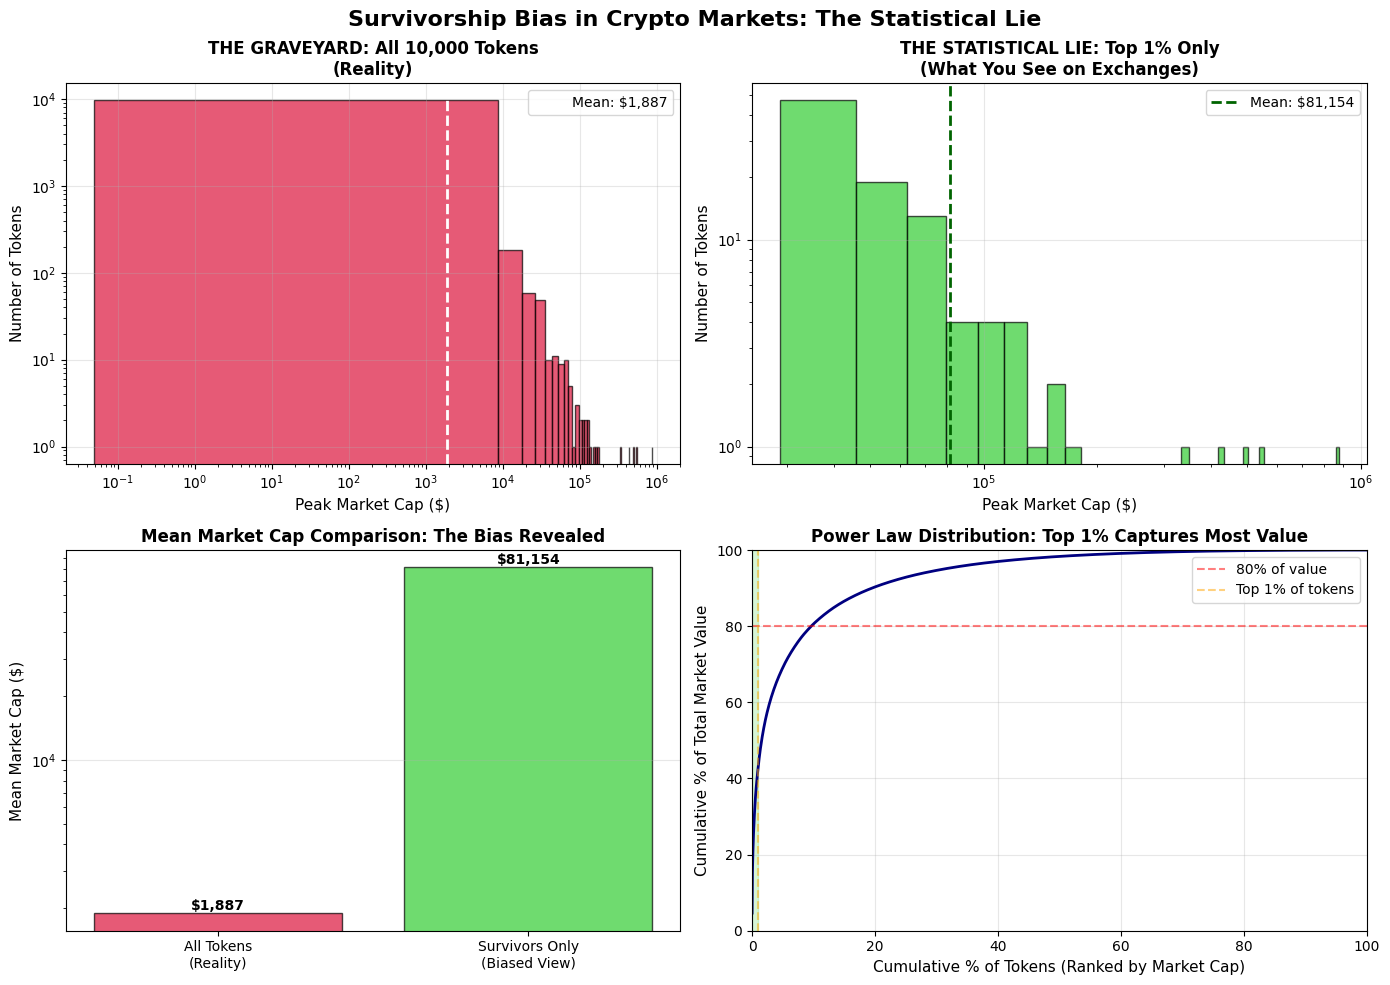


KEY INSIGHT:
If you only analyze 'listed' tokens (survivors), you're not seeing
98.6% of the market. Your risk model is fundamentally broken.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

print("=" * 70)
print("CRYPTO TOKEN SURVIVORSHIP BIAS SIMULATION")
print("Simulating 10,000 token launches on Pump.fun-like platform")
print("=" * 70)

# Simulation parameters
n_tokens = 10_000
survival_rate = 0.01  # Top 1% survive (99% fail)

# Generate Peak Market Cap using Pareto Distribution (Power Law)
# Shape parameter (alpha) controls inequality - lower = more extreme
# Scale parameter controls minimum value
alpha = 1.5  # Creates extreme inequality (realistic for crypto)
scale = 100  # Minimum market cap in dollars

# Generate market caps with Pareto distribution
market_caps = (np.random.pareto(alpha, n_tokens) + 1) * scale

# Add some noise and create more realistic distribution
# Most tokens should be near zero, few should be massive
market_caps = market_caps * np.random.lognormal(0, 2, n_tokens)

# Create DataFrame with all tokens (THE GRAVEYARD)
df_all = pd.DataFrame({
    'Token_ID': range(1, n_tokens + 1),
    'Peak_Market_Cap': market_caps,
    'Status': 'Failed'
})

# Identify survivors (top 1% by market cap)
threshold = df_all['Peak_Market_Cap'].quantile(1 - survival_rate)
df_all.loc[df_all['Peak_Market_Cap'] >= threshold, 'Status'] = 'Survived'

# Create survivors-only DataFrame (THE STATISTICAL LIE)
df_survivors = df_all[df_all['Status'] == 'Survived'].copy()

# Calculate key statistics
mean_all = df_all['Peak_Market_Cap'].mean()
median_all = df_all['Peak_Market_Cap'].median()
mean_survivors = df_survivors['Peak_Market_Cap'].mean()
median_survivors = df_survivors['Peak_Market_Cap'].median()

print(f"\n📊 SIMULATION RESULTS:")
print(f"Total tokens launched: {len(df_all):,}")
print(f"Survivors (Top 1%): {len(df_survivors):,}")
print(f"Failed tokens: {len(df_all) - len(df_survivors):,}")

print(f"\n💀 THE GRAVEYARD (All Tokens):")
print(f"Mean Market Cap: ${mean_all:,.2f}")
print(f"Median Market Cap: ${median_all:,.2f}")

print(f"\n🚀 THE SURVIVORS (Top 1% Only):")
print(f"Mean Market Cap: ${mean_survivors:,.2f}")
print(f"Median Market Cap: ${median_survivors:,.2f}")

print(f"\n⚠️  SURVIVORSHIP BIAS MAGNITUDE:")
bias_multiplier = mean_survivors / mean_all
print(f"Survivors' mean is {bias_multiplier:.1f}x higher than reality")
print(f"Analyzing only survivors inflates expectations by {(bias_multiplier - 1) * 100:.0f}%")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Survivorship Bias in Crypto Markets: The Statistical Lie',
             fontsize=16, fontweight='bold')

# Plot 1: Distribution of all tokens (log scale)
ax1 = axes[0, 0]
ax1.hist(df_all['Peak_Market_Cap'], bins=100, color='crimson',
         alpha=0.7, edgecolor='black')
ax1.axvline(mean_all, color='white', linestyle='--', linewidth=2,
            label=f'Mean: ${mean_all:,.0f}')
ax1.set_xlabel('Peak Market Cap ($)', fontsize=11)
ax1.set_ylabel('Number of Tokens', fontsize=11)
ax1.set_title('THE GRAVEYARD: All 10,000 Tokens\n(Reality)', fontweight='bold')
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of survivors only (log scale)
ax2 = axes[0, 1]
ax2.hist(df_survivors['Peak_Market_Cap'], bins=50, color='limegreen',
         alpha=0.7, edgecolor='black')
ax2.axvline(mean_survivors, color='darkgreen', linestyle='--', linewidth=2,
            label=f'Mean: ${mean_survivors:,.0f}')
ax2.set_xlabel('Peak Market Cap ($)', fontsize=11)
ax2.set_ylabel('Number of Tokens', fontsize=11)
ax2.set_title('THE STATISTICAL LIE: Top 1% Only\n(What You See on Exchanges)',
              fontweight='bold')
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Comparison bar chart
ax3 = axes[1, 0]
comparison = pd.DataFrame({
    'Dataset': ['All Tokens\n(Reality)', 'Survivors Only\n(Biased View)'],
    'Mean Market Cap': [mean_all, mean_survivors]
})
bars = ax3.bar(comparison['Dataset'], comparison['Mean Market Cap'],
               color=['crimson', 'limegreen'], alpha=0.7, edgecolor='black')
ax3.set_ylabel('Mean Market Cap ($)', fontsize=11)
ax3.set_title('Mean Market Cap Comparison: The Bias Revealed', fontweight='bold')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 4: Cumulative distribution showing concentration
ax4 = axes[1, 1]
sorted_caps = np.sort(df_all['Peak_Market_Cap'].values)[::-1]
cumulative_pct = np.arange(1, len(sorted_caps) + 1) / len(sorted_caps) * 100
cumulative_value = np.cumsum(sorted_caps) / np.sum(sorted_caps) * 100

ax4.plot(cumulative_pct, cumulative_value, linewidth=2, color='navy')
ax4.axhline(80, color='red', linestyle='--', alpha=0.5, label='80% of value')
ax4.axvline(1, color='orange', linestyle='--', alpha=0.5, label='Top 1% of tokens')
ax4.fill_between([0, 1], [0, 0], [100, 100], alpha=0.2, color='limegreen')
ax4.set_xlabel('Cumulative % of Tokens (Ranked by Market Cap)', fontsize=11)
ax4.set_ylabel('Cumulative % of Total Market Value', fontsize=11)
ax4.set_title('Power Law Distribution: Top 1% Captures Most Value', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 100)
ax4.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("KEY INSIGHT:")
print("If you only analyze 'listed' tokens (survivors), you're not seeing")
print("98.6% of the market. Your risk model is fundamentally broken.")
print("=" * 70)